# Benchmark result plots for single modes and hybrid modes

This notebook reads the raw benchmark result CSVs, builds aggregate tables from successful runs, and plots the results separately for:

1. single-mode runs  
2. hybrid-mode runs  

In [14]:
# imports + file paths

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

single_results_path = Path("screen_test_4096_20260423_102458_results.csv")
hybrid_results_path = Path("hybrid_screen_test_20260423_111519_results.csv")

# Fallbacks if you copy the files locally into the notebook directory
if not single_results_path.exists():
    single_results_path = Path("screen_test_4096_20260423_102458_results.csv")

if not hybrid_results_path.exists():
    hybrid_results_path = Path("hybrid_screen_test_20260423_111519_results.csv")

print("Single results path :", single_results_path)
print("Hybrid results path :", hybrid_results_path)
print("Single exists       :", single_results_path.exists())
print("Hybrid exists       :", hybrid_results_path.exists())

Single results path : screen_test_4096_20260423_102458_results.csv
Hybrid results path : hybrid_screen_test_20260423_111519_results.csv
Single exists       : True
Hybrid exists       : True


In [15]:
# load raw results

single_raw_df = pd.read_csv(single_results_path)
hybrid_raw_df = pd.read_csv(hybrid_results_path)

# Normalize workload column name
single_raw_df["workload_name"] = single_raw_df.get("workload_key", single_raw_df.get("workload_name"))
hybrid_raw_df["workload_name"] = hybrid_raw_df.get("workload_key", hybrid_raw_df.get("workload_name"))

single_ok_df = single_raw_df[single_raw_df["success"] == True].copy()
hybrid_ok_df = hybrid_raw_df[hybrid_raw_df["success"] == True].copy()

print("Single raw shape   :", single_raw_df.shape)
print("Single success rows:", single_ok_df.shape)
print("Hybrid raw shape   :", hybrid_raw_df.shape)
print("Hybrid success rows:", hybrid_ok_df.shape)

display(single_ok_df.head())
display(hybrid_ok_df.head())

Single raw shape   : (180, 53)
Single success rows: (180, 53)
Hybrid raw shape   : (100, 53)
Hybrid success rows: (100, 53)


,mode_name,workload_name,backend,trial_index,prompt_tokens_target,max_new_tokens,repeated_prefix,memory_pressure,num_requests_in_batch,start_time_s,...,reference_rouge_l_f1,reference_token_f1,baseline_similarity_rouge_l_f1,quality_degradation_vs_baseline,notes,error,error_type,success,workload_key,log_file
0,fp16_baseline,ctx3840_out256,vllm,14,3840,256,False,True,1,1453.875405,...,NaN,NaN,NaN,NaN,Primary trusted metrics for this run: total la...,NaN,NaN,True,ctx3840_out256,screen_test_4096_20260423_102458_0001_fp16_bas...
1,int8_quant,ctx3840_out256,vllm,4,3840,256,False,True,1,1469.729514,...,NaN,NaN,NaN,NaN,Primary trusted metrics for this run: total la...,NaN,NaN,True,ctx3840_out256,screen_test_4096_20260423_102458_0002_int8_qua...
2,gptq_4bit,ctx3840_out256,vllm,1,3840,256,False,True,1,1482.828603,...,NaN,NaN,NaN,NaN,Primary trusted metrics for this run: total la...,NaN,NaN,True,ctx3840_out256,screen_test_4096_20260423_102458_0003_gptq_4bi...
3,speculative_decoding,ctx4032_out64,vllm,3,4032,64,False,True,1,1508.478819,...,NaN,NaN,NaN,NaN,Primary trusted metrics for this run: total la...,NaN,NaN,True,ctx4032_out64,screen_test_4096_20260423_102458_0004_speculat...
4,fp16_baseline,ctx3840_out256,vllm,1,3840,256,False,True,1,1521.747944,...,NaN,NaN,NaN,NaN,Primary trusted metrics for this run: total la...,NaN,NaN,True,ctx3840_out256,screen_test_4096_20260423_102458_0005_fp16_bas...


,mode_name,workload_name,backend,trial_index,prompt_tokens_target,max_new_tokens,repeated_prefix,memory_pressure,num_requests_in_batch,start_time_s,...,reference_rouge_l_f1,reference_token_f1,baseline_similarity_rouge_l_f1,quality_degradation_vs_baseline,notes,error,error_type,success,workload_key,log_file
0,int8_plus_chunked_prefill,ctx3840_out256,vllm,6,3840,256,False,True,1,4451.857727,...,NaN,NaN,NaN,NaN,Primary trusted metrics for this run: total la...,NaN,NaN,True,ctx3840_out256,hybrid_screen_test_20260423_111519_0001_int8_p...
1,int8_plus_chunked_prefill,ctx4032_out64,vllm,9,4032,64,False,True,1,4465.874464,...,NaN,NaN,NaN,NaN,Primary trusted metrics for this run: total la...,NaN,NaN,True,ctx4032_out64,hybrid_screen_test_20260423_111519_0002_int8_p...
2,gptq_plus_prefix_caching,shared4032_out64,vllm,1,4032,64,True,True,1,4477.798661,...,NaN,NaN,NaN,NaN,Timed follow-up request after priming a shared...,NaN,NaN,True,shared4032_out64,hybrid_screen_test_20260423_111519_0003_gptq_p...
3,int8_plus_chunked_prefill,ctx3840_out256,vllm,2,3840,256,False,True,1,4489.284767,...,NaN,NaN,NaN,NaN,Primary trusted metrics for this run: total la...,NaN,NaN,True,ctx3840_out256,hybrid_screen_test_20260423_111519_0004_int8_p...
4,int8_plus_prefix_caching,shared4032_out64,vllm,2,4032,64,True,True,1,4504.130599,...,NaN,NaN,NaN,NaN,Timed follow-up request after priming a shared...,NaN,NaN,True,shared4032_out64,hybrid_screen_test_20260423_111519_0005_int8_p...


In [16]:
# helper functions for summaries

def pctl(x, q):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.percentile(x, q))

def mean_ci_bounds(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    if n == 0:
        return (np.nan, np.nan, np.nan)

    mean = float(x.mean())
    if n == 1:
        return (mean, mean, mean)

    std = float(x.std(ddof=1))
    half = 1.96 * std / math.sqrt(n)
    return (mean, mean - half, mean + half)

def summarize_metric(series, prefix):
    s = pd.Series(series).dropna().astype(float)
    mean, ci_lo, ci_hi = mean_ci_bounds(s)

    return {
        f"{prefix}_mean": mean,
        f"{prefix}_std": float(s.std(ddof=1)) if len(s) > 1 else (0.0 if len(s) == 1 else np.nan),
        f"{prefix}_median": float(s.median()) if len(s) else np.nan,
        f"{prefix}_p95": pctl(s, 95),
        f"{prefix}_ci95_low": ci_lo,
        f"{prefix}_ci95_high": ci_hi,
    }

def build_aggregate_table(ok_df):
    rows = []

    for (mode_name, workload_name), group in ok_df.groupby(["mode_name", "workload_name"], sort=False):
        row = {
            "mode_name": mode_name,
            "workload_name": workload_name,
            "num_runs": len(group),
        }
        row.update(summarize_metric(group["ttft_ms"], "ttft_ms"))
        row.update(summarize_metric(group["prefill_latency_ms"], "prefill_latency_ms"))
        row.update(summarize_metric(group["decode_latency_ms"], "decode_latency_ms"))
        row.update(summarize_metric(group["total_latency_ms"], "total_latency_ms"))
        row.update(summarize_metric(group["tokens_per_second"], "tokens_per_second"))
        row.update(summarize_metric(group["energy_per_token_j"], "energy_per_token_j"))
        row.update(summarize_metric(group["peak_gpu_memory_mb"], "peak_gpu_memory_mb"))
        rows.append(row)

    return pd.DataFrame(rows)

def build_reference_comparison(ok_df, reference_mode):
    ref_df = ok_df[ok_df["mode_name"] == reference_mode][
        ["workload_name", "trial_index", "total_latency_ms", "tokens_per_second", "energy_per_token_j"]
    ].rename(
        columns={
            "total_latency_ms": "ref_total_latency_ms",
            "tokens_per_second": "ref_tokens_per_second",
            "energy_per_token_j": "ref_energy_per_token_j",
        }
    )

    pair_df = ok_df.merge(ref_df, on=["workload_name", "trial_index"], how="inner")
    pair_df = pair_df[pair_df["mode_name"] != reference_mode].copy()

    pair_df["latency_speedup_vs_ref"] = pair_df["ref_total_latency_ms"] / pair_df["total_latency_ms"]
    pair_df["throughput_ratio_vs_ref"] = pair_df["tokens_per_second"] / pair_df["ref_tokens_per_second"]
    pair_df["energy_ratio_vs_ref"] = pair_df["energy_per_token_j"] / pair_df["ref_energy_per_token_j"]
    pair_df["latency_delta_ms_vs_ref"] = pair_df["total_latency_ms"] - pair_df["ref_total_latency_ms"]

    rows = []
    for (mode_name, workload_name), group in pair_df.groupby(["mode_name", "workload_name"], sort=False):
        row = {
            "mode_name": mode_name,
            "workload_name": workload_name,
            "num_paired_runs": len(group),
        }
        row.update(summarize_metric(group["latency_speedup_vs_ref"], "latency_speedup_vs_ref"))
        row.update(summarize_metric(group["throughput_ratio_vs_ref"], "throughput_ratio_vs_ref"))
        row.update(summarize_metric(group["energy_ratio_vs_ref"], "energy_ratio_vs_ref"))
        row.update(summarize_metric(group["latency_delta_ms_vs_ref"], "latency_delta_ms_vs_ref"))
        rows.append(row)

    return pd.DataFrame(rows), pair_df

In [17]:
# build aggregate and comparison tables

single_agg_df = build_aggregate_table(single_ok_df)
hybrid_agg_df = build_aggregate_table(hybrid_ok_df)

single_reference_mode = "fp16_baseline"
single_cmp_df, single_pair_df = build_reference_comparison(single_ok_df, single_reference_mode)

print("Single aggregate table")
display(single_agg_df.sort_values(["workload_name", "total_latency_ms_mean"], ascending=[True, True]))

print("Hybrid aggregate table")
display(hybrid_agg_df.sort_values(["workload_name", "total_latency_ms_mean"], ascending=[True, True]))

print("Single-mode comparison table vs fp16_baseline")
display(single_cmp_df.sort_values(["workload_name", "latency_speedup_vs_ref_mean"], ascending=[True, False]))

Single aggregate table


,mode_name,workload_name,num_runs,ttft_ms_mean,ttft_ms_std,ttft_ms_median,ttft_ms_p95,ttft_ms_ci95_low,ttft_ms_ci95_high,prefill_latency_ms_mean,...,energy_per_token_j_median,energy_per_token_j_p95,energy_per_token_j_ci95_low,energy_per_token_j_ci95_high,peak_gpu_memory_mb_mean,peak_gpu_memory_mb_std,peak_gpu_memory_mb_median,peak_gpu_memory_mb_p95,peak_gpu_memory_mb_ci95_low,peak_gpu_memory_mb_ci95_high
5,speculative_decoding,ctx3840_out256,15,347.581283,9.549874,350.905374,361.096109,342.748380,352.414186,347.581283,...,1.797119,1.857773,1.777175,1.816984,33519.218783,67.848200,33552.085449,33562.622949,33484.882856,33553.554709
2,gptq_4bit,ctx3840_out256,15,315.684524,11.551320,315.029508,333.702072,309.838749,321.530299,315.684524,...,2.003801,2.044962,1.913662,2.000901,33524.150716,86.965737,33563.942383,33563.942383,33480.139981,33568.161451
1,int8_quant,ctx3840_out256,15,219.573244,9.283027,218.093819,232.266142,214.875384,224.271104,219.573244,...,2.310281,2.456585,2.283813,2.368680,33498.859049,104.732990,33556.192383,33556.192383,33445.856844,33551.861255
8,chunked_prefill,ctx3840_out256,15,308.610545,11.369604,306.077489,322.844848,302.856731,314.364358,308.610545,...,3.789747,3.830921,3.776418,3.803275,33523.860026,48.426506,33550.943359,33550.943359,33499.352833,33548.367219
0,fp16_baseline,ctx3840_out256,15,276.739055,0.960701,276.432783,277.967724,276.252873,277.225237,276.739055,...,4.330163,4.405408,4.278851,4.346778,33466.681641,139.891779,33526.556641,33550.931641,33395.886633,33537.476649
6,gptq_4bit,ctx4032_out64,15,322.911895,10.883253,319.004070,344.488941,317.404210,328.419581,322.911895,...,2.857030,3.016391,2.731664,2.895201,33536.696777,59.246477,33570.821777,33578.946777,33506.713923,33566.679632
3,speculative_decoding,ctx4032_out64,15,358.464214,7.791224,360.585725,370.077275,354.521311,362.407118,358.464214,...,2.979842,3.195902,2.894122,3.040849,33515.102083,85.295736,33548.468750,33583.381250,33471.936485,33558.267682
9,int8_quant,ctx4032_out64,15,229.617727,8.159835,230.547786,239.980099,225.488281,233.747174,229.617727,...,2.933425,2.961762,2.880984,2.931477,33551.492350,42.537711,33576.950684,33579.388184,33529.965298,33573.019402
7,chunked_prefill,ctx4032_out64,15,311.862099,10.702592,308.690387,325.286372,306.445840,317.278358,311.862099,...,4.771770,5.076913,4.716650,4.876125,33549.609993,53.607691,33571.701660,33579.539160,33522.480759,33576.739228
4,fp16_baseline,ctx4032_out64,15,282.056702,0.708764,281.791385,282.908948,281.698017,282.415386,282.056702,...,5.677295,5.792416,5.481180,5.680281,33528.356608,82.554996,33571.689941,33571.689941,33486.578016,33570.135200


Hybrid aggregate table


,mode_name,workload_name,num_runs,ttft_ms_mean,ttft_ms_std,ttft_ms_median,ttft_ms_p95,ttft_ms_ci95_low,ttft_ms_ci95_high,prefill_latency_ms_mean,...,energy_per_token_j_median,energy_per_token_j_p95,energy_per_token_j_ci95_low,energy_per_token_j_ci95_high,peak_gpu_memory_mb_mean,peak_gpu_memory_mb_std,peak_gpu_memory_mb_median,peak_gpu_memory_mb_p95,peak_gpu_memory_mb_ci95_low,peak_gpu_memory_mb_ci95_high
7,int8_plus_continuous_batching,ctx2048_out64,10,234.742493,6.914066,232.855107,246.447729,230.457110,239.027875,234.742493,...,1.085437,1.138801,1.055699,1.109484,33377.311523,0.0,33377.311523,33377.311523,33377.311523,33377.311523
8,gptq_plus_continuous_batching,ctx2048_out64,10,344.721096,8.145381,345.205010,354.844621,339.672537,349.769656,344.721096,...,1.437064,1.505711,1.403541,1.466284,33487.538086,0.0,33487.538086,33487.538086,33487.538086,33487.538086
9,speculative_plus_chunked_prefill,ctx3840_out256,10,352.571661,7.510350,354.737288,360.600395,347.916698,357.226624,352.571661,...,1.809497,1.869104,1.763249,1.835059,33587.211426,0.0,33587.211426,33587.211426,33587.211426,33587.211426
4,gptq_plus_chunked_prefill,ctx3840_out256,10,317.226280,12.704019,318.348907,335.079608,309.352247,325.100312,317.226280,...,1.821096,1.916679,1.786302,1.864845,33625.943359,0.0,33625.943359,33625.943359,33625.943359,33625.943359
0,int8_plus_chunked_prefill,ctx3840_out256,10,226.571440,8.348656,226.498686,237.394798,221.396889,231.745991,226.571440,...,2.296398,2.330255,2.273498,2.310898,33564.318359,0.0,33564.318359,33564.318359,33564.318359,33564.318359
6,gptq_plus_chunked_prefill,ctx4032_out64,10,322.989967,9.472861,324.648918,334.025666,317.118626,328.861307,322.989967,...,2.828007,2.968543,2.755982,2.911669,33640.947754,0.0,33640.947754,33640.947754,33640.947754,33640.947754
5,speculative_plus_chunked_prefill,ctx4032_out64,10,361.943531,12.302790,363.774000,377.904238,354.318183,369.568879,361.943531,...,2.917812,3.133383,2.867615,3.021370,33607.969727,0.0,33607.969727,33607.969727,33607.969727,33607.969727
1,int8_plus_chunked_prefill,ctx4032_out64,10,233.316081,7.876112,235.267009,243.202753,228.434417,238.197746,233.316081,...,3.014707,3.198479,2.949603,3.093098,33585.076660,0.0,33585.076660,33585.076660,33585.076660,33585.076660
2,gptq_plus_prefix_caching,shared4032_out64,10,54.320555,0.674917,54.308728,55.329280,53.902237,54.738873,54.320555,...,2.098133,2.216443,1.955011,2.143714,33634.139160,0.0,33634.139160,33634.139160,33634.139160,33634.139160
3,int8_plus_prefix_caching,shared4032_out64,10,49.615741,0.490206,49.590117,50.323932,49.311908,49.919574,49.615741,...,2.443211,2.540564,2.359809,2.491272,33574.514160,0.0,33574.514160,33574.514160,33574.514160,33574.514160


Single-mode comparison table vs fp16_baseline


,mode_name,workload_name,num_paired_runs,latency_speedup_vs_ref_mean,latency_speedup_vs_ref_std,latency_speedup_vs_ref_median,latency_speedup_vs_ref_p95,latency_speedup_vs_ref_ci95_low,latency_speedup_vs_ref_ci95_high,throughput_ratio_vs_ref_mean,...,energy_ratio_vs_ref_median,energy_ratio_vs_ref_p95,energy_ratio_vs_ref_ci95_low,energy_ratio_vs_ref_ci95_high,latency_delta_ms_vs_ref_mean,latency_delta_ms_vs_ref_std,latency_delta_ms_vs_ref_median,latency_delta_ms_vs_ref_p95,latency_delta_ms_vs_ref_ci95_low,latency_delta_ms_vs_ref_ci95_high
3,speculative_decoding,ctx3840_out256,15,2.630612,0.040320,2.622035,2.713055,2.610207,2.651016,2.630612,...,0.415696,0.432792,0.410671,0.422935,-3581.189973,71.528617,-3561.188345,-3497.328466,-3617.388447,-3544.991498
1,gptq_4bit,ctx3840_out256,15,2.356920,0.169590,2.284324,2.647048,2.271096,2.442745,2.356920,...,0.462682,0.474510,0.444212,0.463468,-3315.291274,175.426224,-3251.498167,-3136.058972,-3404.069193,-3226.513356
0,int8_quant,ctx3840_out256,15,1.869894,0.044617,1.876571,1.924346,1.847315,1.892474,1.869894,...,0.536722,0.576806,0.529223,0.549724,-2686.508263,95.603846,-2691.344323,-2537.366346,-2734.890485,-2638.126042
6,chunked_prefill,ctx3840_out256,15,1.398204,0.021566,1.402575,1.425212,1.387291,1.409118,1.398204,...,0.880070,0.901025,0.871443,0.886430,-1645.073868,79.550475,-1654.240859,-1522.489836,-1685.331963,-1604.815772
4,gptq_4bit,ctx4032_out64,15,2.100629,0.028641,2.102579,2.137292,2.086134,2.115123,2.100629,...,0.506457,0.553056,0.486554,0.523153,-867.000071,20.467272,-866.974816,-840.843755,-877.357940,-856.642203
2,speculative_decoding,ctx4032_out64,15,2.062481,0.035140,2.049473,2.115243,2.044698,2.080264,2.062481,...,0.527503,0.593767,0.513926,0.551307,-852.410096,24.370104,-846.190903,-824.653544,-864.743070,-840.077121
7,int8_quant,ctx4032_out64,15,1.784495,0.034107,1.783964,1.831974,1.767235,1.801756,1.784495,...,0.519475,0.548327,0.512793,0.529689,-727.404695,27.806133,-724.292461,-692.553186,-741.476539,-713.332850
5,chunked_prefill,ctx4032_out64,15,1.328706,0.022216,1.332802,1.362455,1.317463,1.339948,1.328706,...,0.841019,0.923981,0.839563,0.881306,-409.294790,25.946439,-410.405498,-372.205429,-422.425500,-396.164081
8,continuous_batching,ctx4032_out64,15,0.896920,0.014143,0.893067,0.918204,0.889763,0.904077,2.410471,...,0.606456,0.644134,0.594233,0.619317,190.230009,26.392846,197.578740,221.455953,176.873386,203.586631


In [18]:
# workload order, mode order, and prettier labels

workload_order = [
    "ctx2048_out64",
    "ctx4032_out64",
    "ctx3840_out256",
    "shared4032_out64",
]

workload_label_map = {
    "ctx2048_out64": "2048 in / 64 out",
    "ctx4032_out64": "4032 in / 64 out",
    "ctx3840_out256": "3840 in / 256 out",
    "shared4032_out64": "shared 4032 / 64 out",
}

single_mode_order = [
    "fp16_baseline",
    "int8_quant",
    "gptq_4bit",
    "speculative_decoding",
    "prefix_caching",
    "chunked_prefill",
    "continuous_batching",
]

hybrid_mode_order = [
    "gptq_plus_chunked_prefill",
    "int8_plus_chunked_prefill",
    "speculative_plus_chunked_prefill",
    "gptq_plus_prefix_caching",
    "int8_plus_prefix_caching",
    "gptq_plus_continuous_batching",
    "int8_plus_continuous_batching",
]

for df in [single_agg_df, hybrid_agg_df, single_cmp_df]:
    df["workload_label"] = df["workload_name"].map(workload_label_map).fillna(df["workload_name"])

single_plot_workloads = [workload_label_map[w] for w in ["ctx4032_out64", "ctx3840_out256", "shared4032_out64"]]
hybrid_plot_workloads = [workload_label_map[w] for w in workload_order]

print("Single plot workloads:", single_plot_workloads)
print("Hybrid plot workloads:", hybrid_plot_workloads)

Single plot workloads: ['4032 in / 64 out', '3840 in / 256 out', 'shared 4032 / 64 out']
Hybrid plot workloads: ['2048 in / 64 out', '4032 in / 64 out', '3840 in / 256 out', 'shared 4032 / 64 out']


## Single-mode results

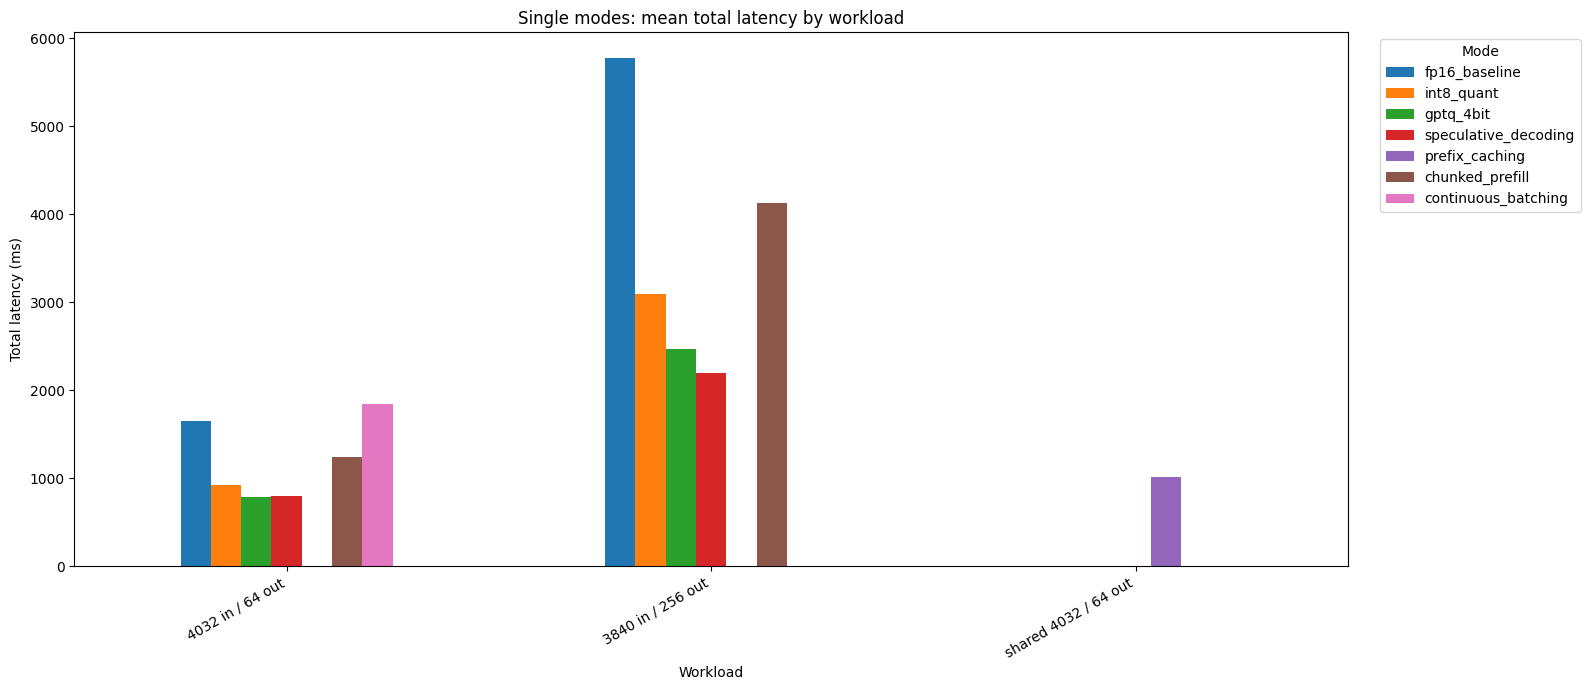

In [19]:
# single modes — total latency

single_latency_pivot = single_agg_df.pivot(
    index="workload_label",
    columns="mode_name",
    values="total_latency_ms_mean"
).reindex(index=single_plot_workloads, columns=single_mode_order)

ax = single_latency_pivot.plot(kind="bar", figsize=(16, 7))
ax.set_title("Single modes: mean total latency by workload")
ax.set_ylabel("Total latency (ms)")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

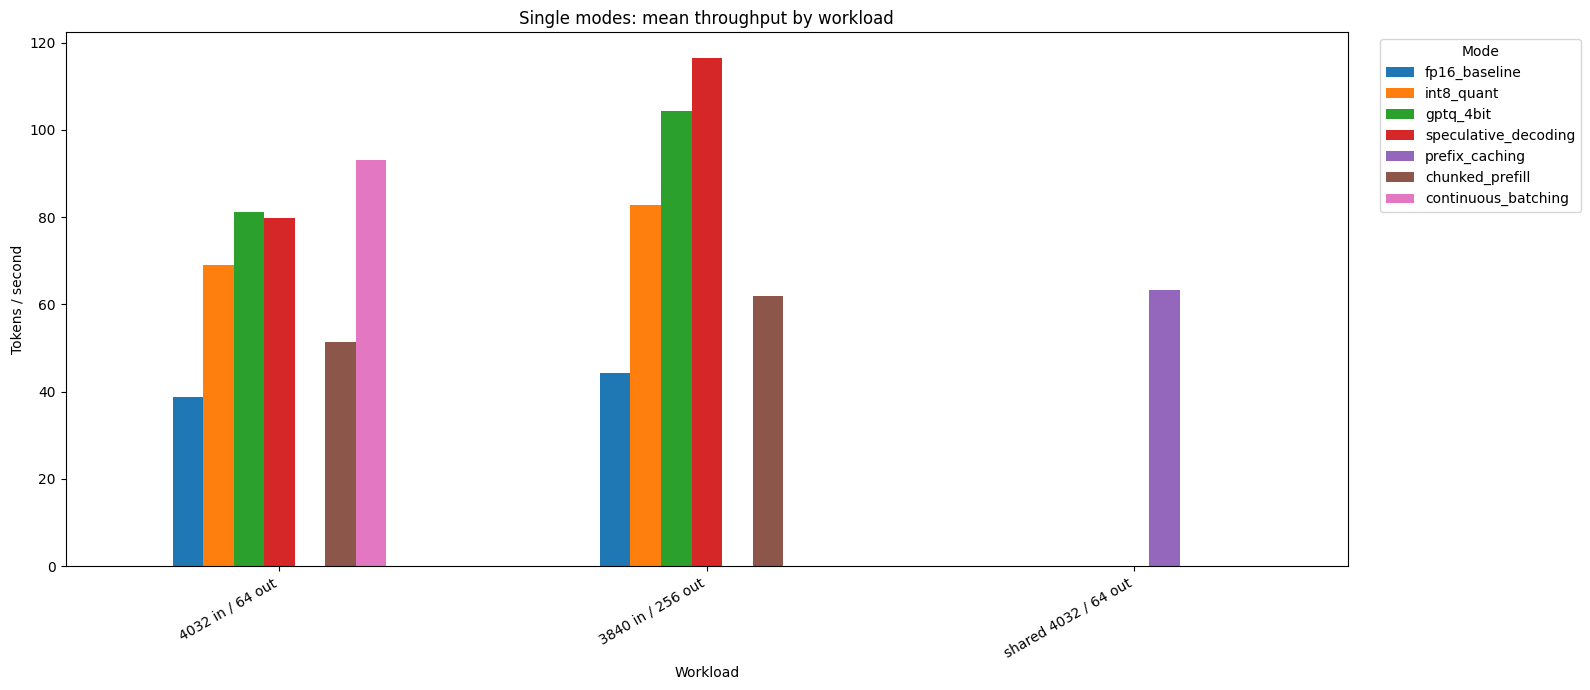

In [20]:
# single modes — throughput

single_tps_pivot = single_agg_df.pivot(
    index="workload_label",
    columns="mode_name",
    values="tokens_per_second_mean"
).reindex(index=single_plot_workloads, columns=single_mode_order)

ax = single_tps_pivot.plot(kind="bar", figsize=(16, 7))
ax.set_title("Single modes: mean throughput by workload")
ax.set_ylabel("Tokens / second")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

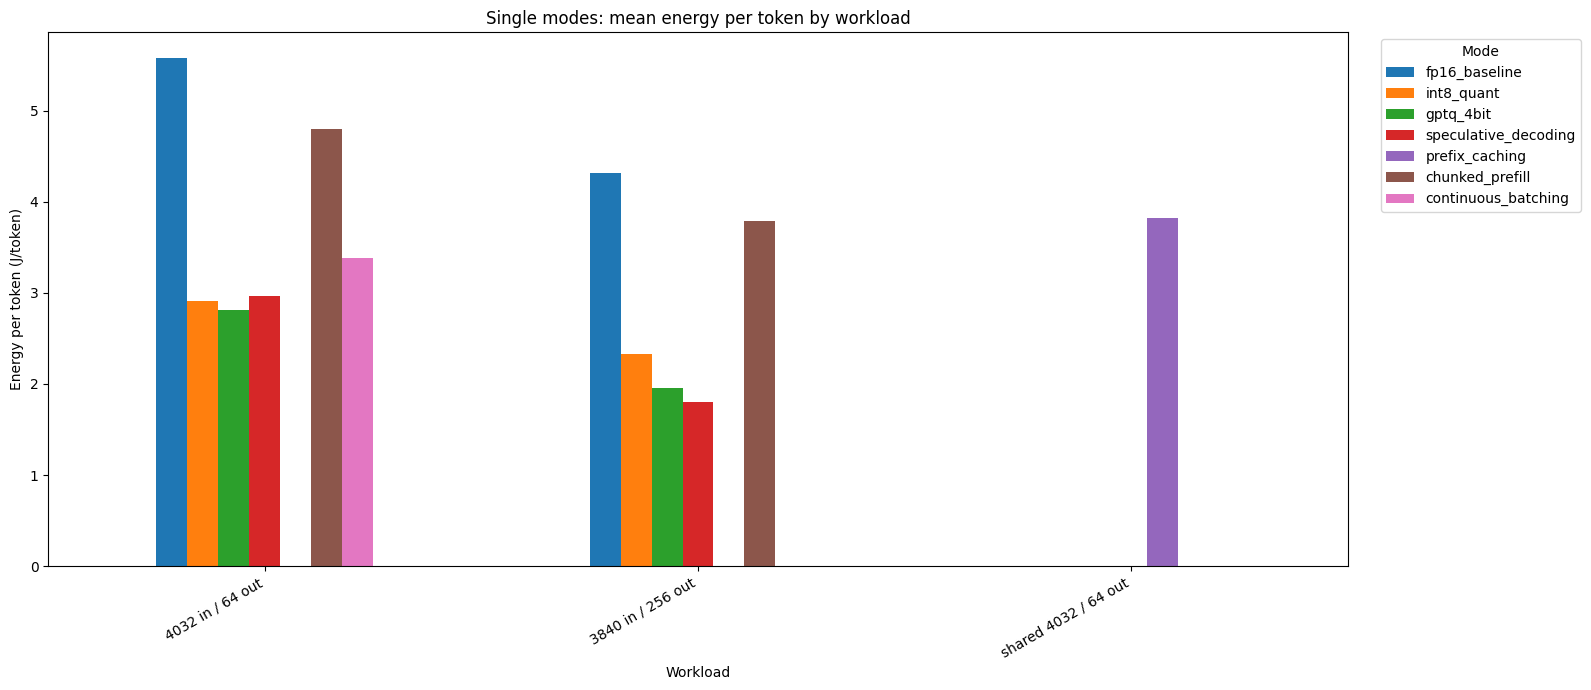

In [21]:
# single modes — energy per token

single_energy_pivot = single_agg_df.pivot(
    index="workload_label",
    columns="mode_name",
    values="energy_per_token_j_mean"
).reindex(index=single_plot_workloads, columns=single_mode_order)

ax = single_energy_pivot.plot(kind="bar", figsize=(16, 7))
ax.set_title("Single modes: mean energy per token by workload")
ax.set_ylabel("Energy per token (J/token)")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

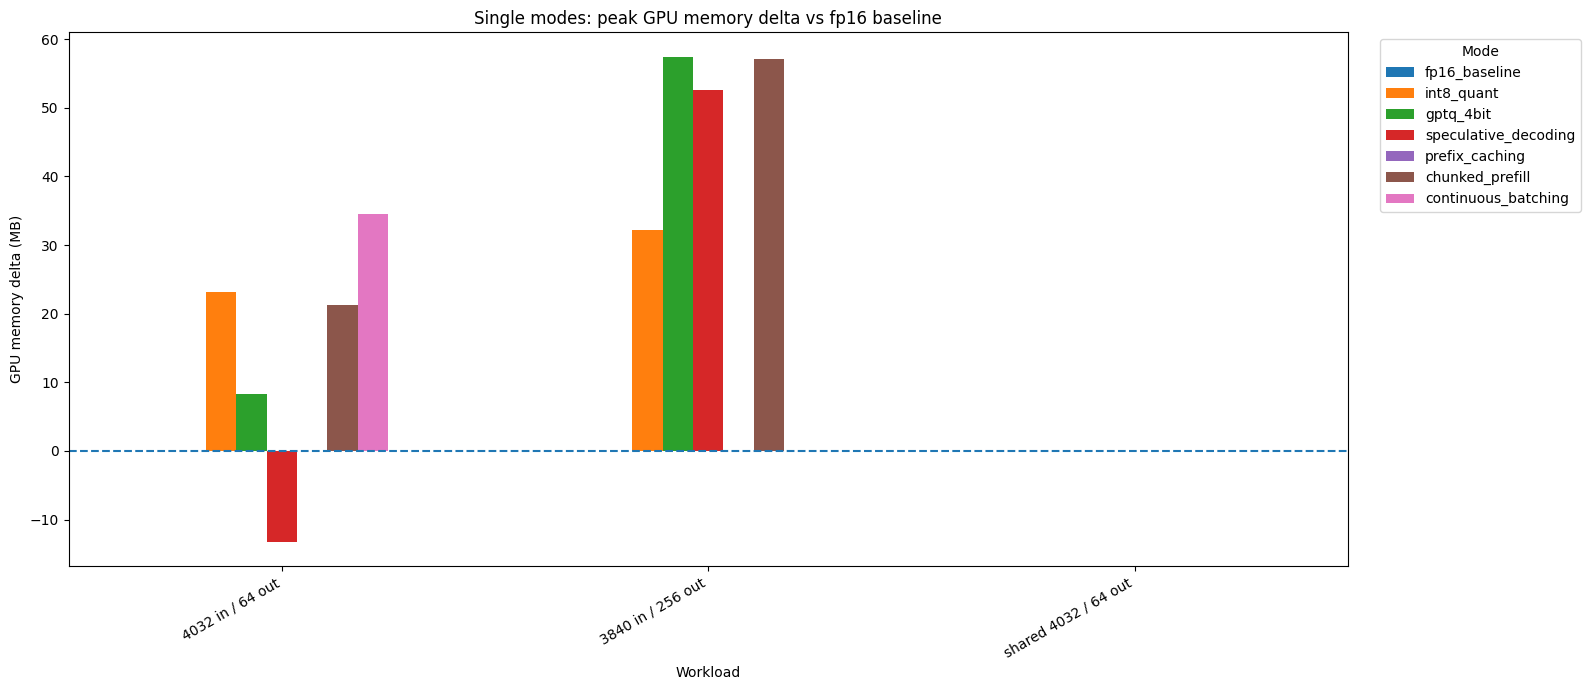

In [28]:
# Cell: single modes — peak GPU memory delta vs fp16 baseline

single_mem_df = single_agg_df[
    ["mode_name", "workload_name", "workload_label", "peak_gpu_memory_mb_mean"]
].copy()

single_mem_baseline = single_mem_df[single_mem_df["mode_name"] == "fp16_baseline"][
    ["workload_name", "peak_gpu_memory_mb_mean"]
].rename(columns={"peak_gpu_memory_mb_mean": "fp16_peak_gpu_memory_mb_mean"})

single_mem_delta_df = single_mem_df.merge(single_mem_baseline, on="workload_name", how="left")
single_mem_delta_df["peak_gpu_memory_delta_mb_vs_fp16"] = (
    single_mem_delta_df["peak_gpu_memory_mb_mean"] - single_mem_delta_df["fp16_peak_gpu_memory_mb_mean"]
)

single_mem_delta_pivot = single_mem_delta_df.pivot(
    index="workload_label",
    columns="mode_name",
    values="peak_gpu_memory_delta_mb_vs_fp16"
).reindex(index=single_plot_workloads, columns=single_mode_order)

ax = single_mem_delta_pivot.plot(kind="bar", figsize=(16, 7))
ax.set_title("Single modes: peak GPU memory delta vs fp16 baseline")
ax.set_ylabel("GPU memory delta (MB)")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.axhline(0, linestyle="--")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

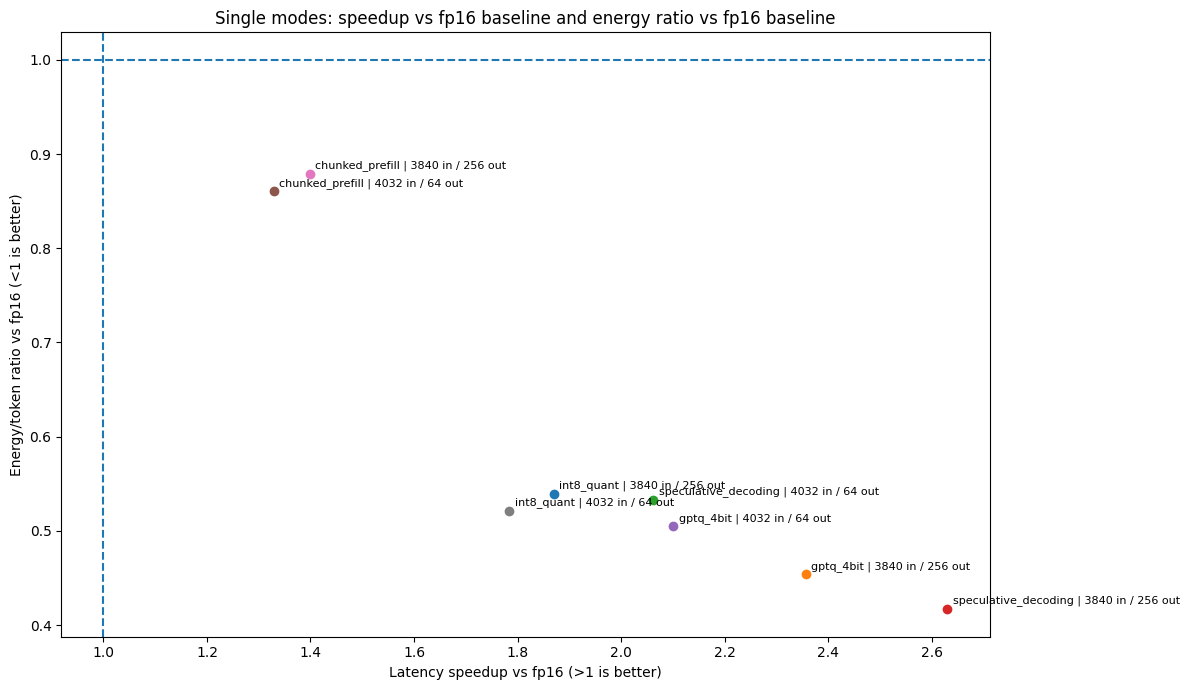

In [29]:
# single modes — speedup vs fp16 baseline and energy ratio vs fp16 baseline

single_scatter_modes = [
    "int8_quant",
    "gptq_4bit",
    "speculative_decoding",
    "prefix_caching",
    "chunked_prefill",
]

single_cmp_main_df = single_cmp_df[single_cmp_df["mode_name"].isin(single_scatter_modes)].copy()

fig, ax = plt.subplots(figsize=(12, 7))

for _, row in single_cmp_main_df.iterrows():
    x = row["latency_speedup_vs_ref_mean"]
    y = row["energy_ratio_vs_ref_mean"]
    label = f"{row['mode_name']} | {row['workload_label']}"
    ax.scatter(x, y)
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(4, 2),                  # slight right/up offset in points
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=8,
    )

ax.axvline(1.0, linestyle="--")
ax.axhline(1.0, linestyle="--")
ax.set_title("Single modes: speedup vs fp16 baseline and energy ratio vs fp16 baseline")
ax.set_xlabel("Latency speedup vs fp16 (>1 is better)")
ax.set_ylabel("Energy/token ratio vs fp16 (<1 is better)")
plt.tight_layout()
plt.show()

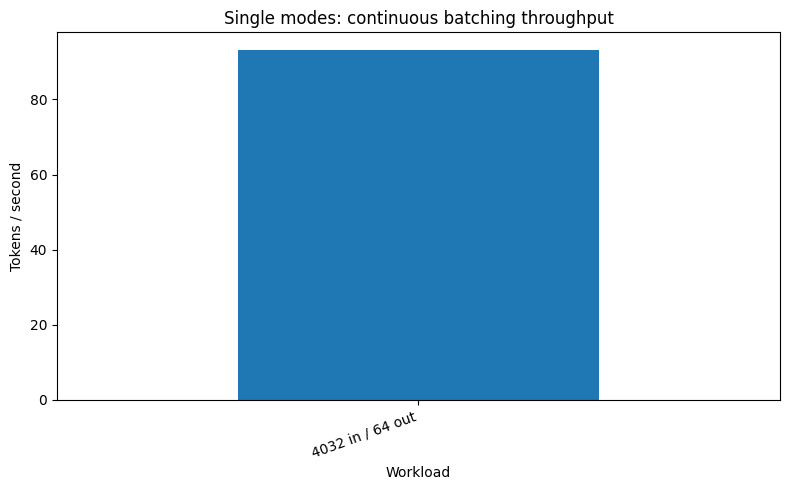

In [24]:
# single modes — continuous batching special-case plot
# This is a throughput-oriented, multi-request scenario, so it is shown separately.

single_cb_df = single_agg_df[single_agg_df["mode_name"] == "continuous_batching"].copy()

ax = single_cb_df.set_index("workload_label")["tokens_per_second_mean"].plot(kind="bar", figsize=(8, 5))
ax.set_title("Single modes: continuous batching throughput")
ax.set_ylabel("Tokens / second")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [32]:
# best single mode per workload by latency

best_single_by_latency = (
    single_agg_df.sort_values(["workload_name", "total_latency_ms_mean"], ascending=[True, True])
    .groupby("workload_name", as_index=False)
    .first()
)

best_single_by_latency = best_single_by_latency[
    [
        "workload_name",
        "mode_name",
        "ttft_ms_mean",
        "total_latency_ms_mean",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]
].copy()

display(best_single_by_latency)

,workload_name,mode_name,ttft_ms_mean,total_latency_ms_mean,tokens_per_second_mean,energy_per_token_j_mean,peak_gpu_memory_mb_mean
0,ctx3840_out256,speculative_decoding,347.581283,2196.529065,116.557155,1.797079,33519.218783
1,ctx4032_out64,gptq_4bit,322.911895,787.842936,81.248281,2.813433,33536.696777
2,shared4032_out64,prefix_caching,52.176757,1009.470977,63.404656,3.821136,33544.347493


## Hybrid-mode results

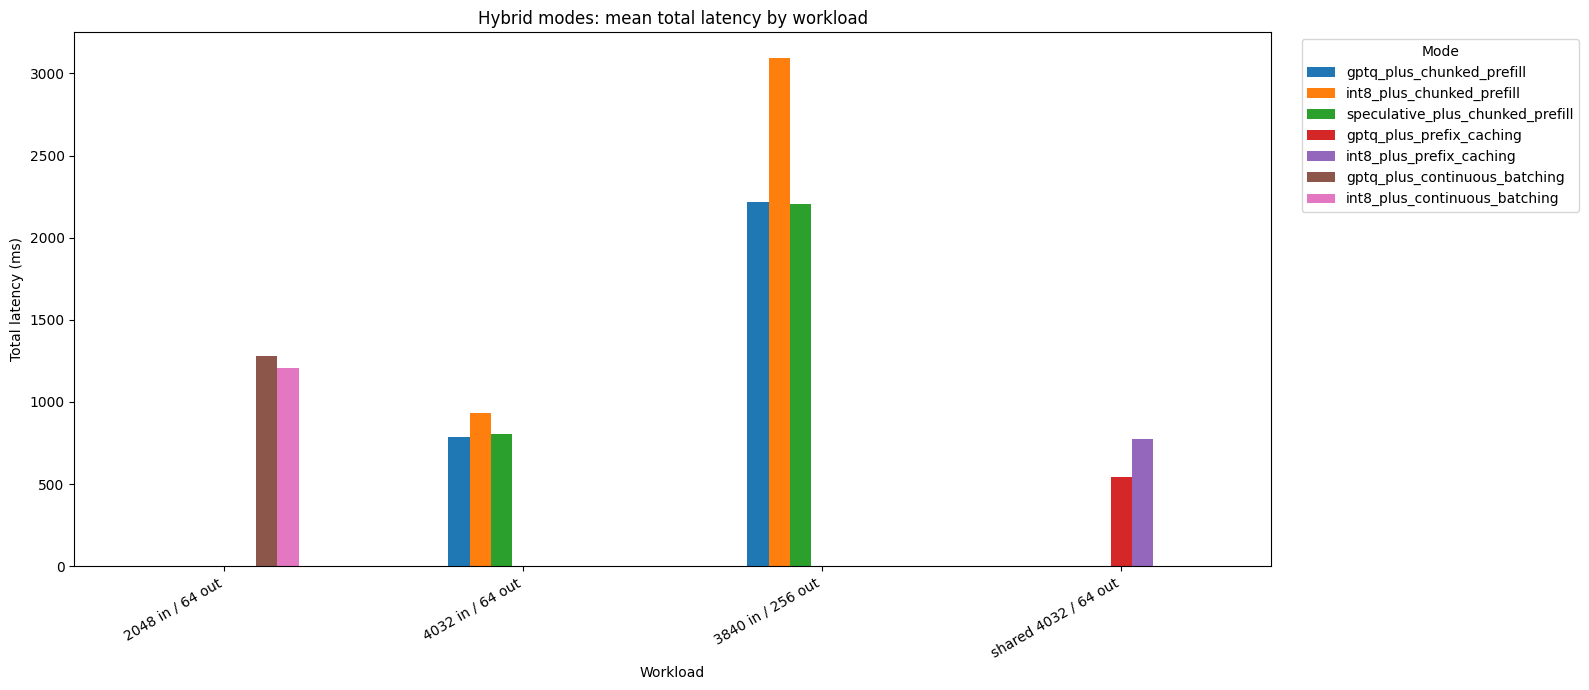

In [33]:
# hybrid modes — total latency

hybrid_latency_pivot = hybrid_agg_df.pivot(
    index="workload_label",
    columns="mode_name",
    values="total_latency_ms_mean"
).reindex(index=hybrid_plot_workloads, columns=hybrid_mode_order)

ax = hybrid_latency_pivot.plot(kind="bar", figsize=(16, 7))
ax.set_title("Hybrid modes: mean total latency by workload")
ax.set_ylabel("Total latency (ms)")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

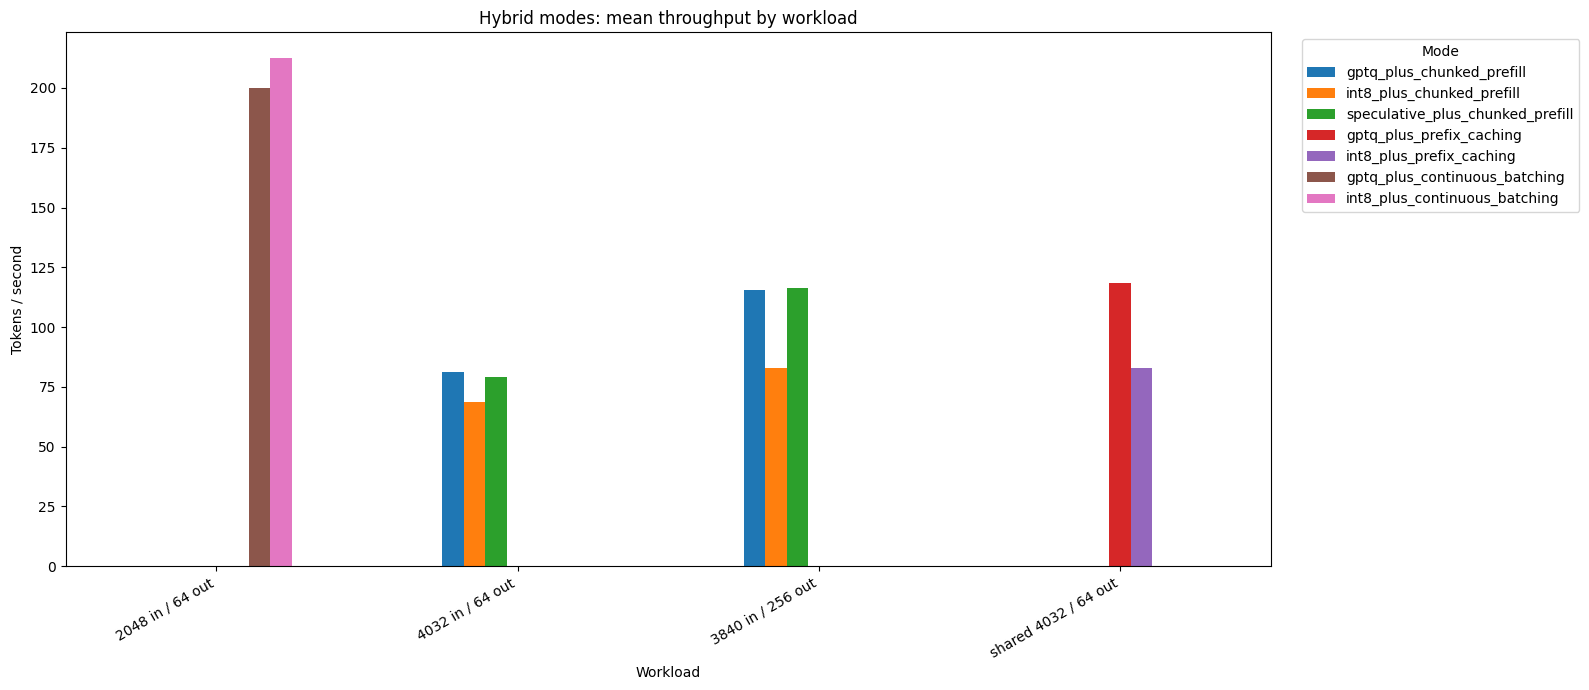

In [34]:
# hybrid modes — throughput

hybrid_tps_pivot = hybrid_agg_df.pivot(
    index="workload_label",
    columns="mode_name",
    values="tokens_per_second_mean"
).reindex(index=hybrid_plot_workloads, columns=hybrid_mode_order)

ax = hybrid_tps_pivot.plot(kind="bar", figsize=(16, 7))
ax.set_title("Hybrid modes: mean throughput by workload")
ax.set_ylabel("Tokens / second")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

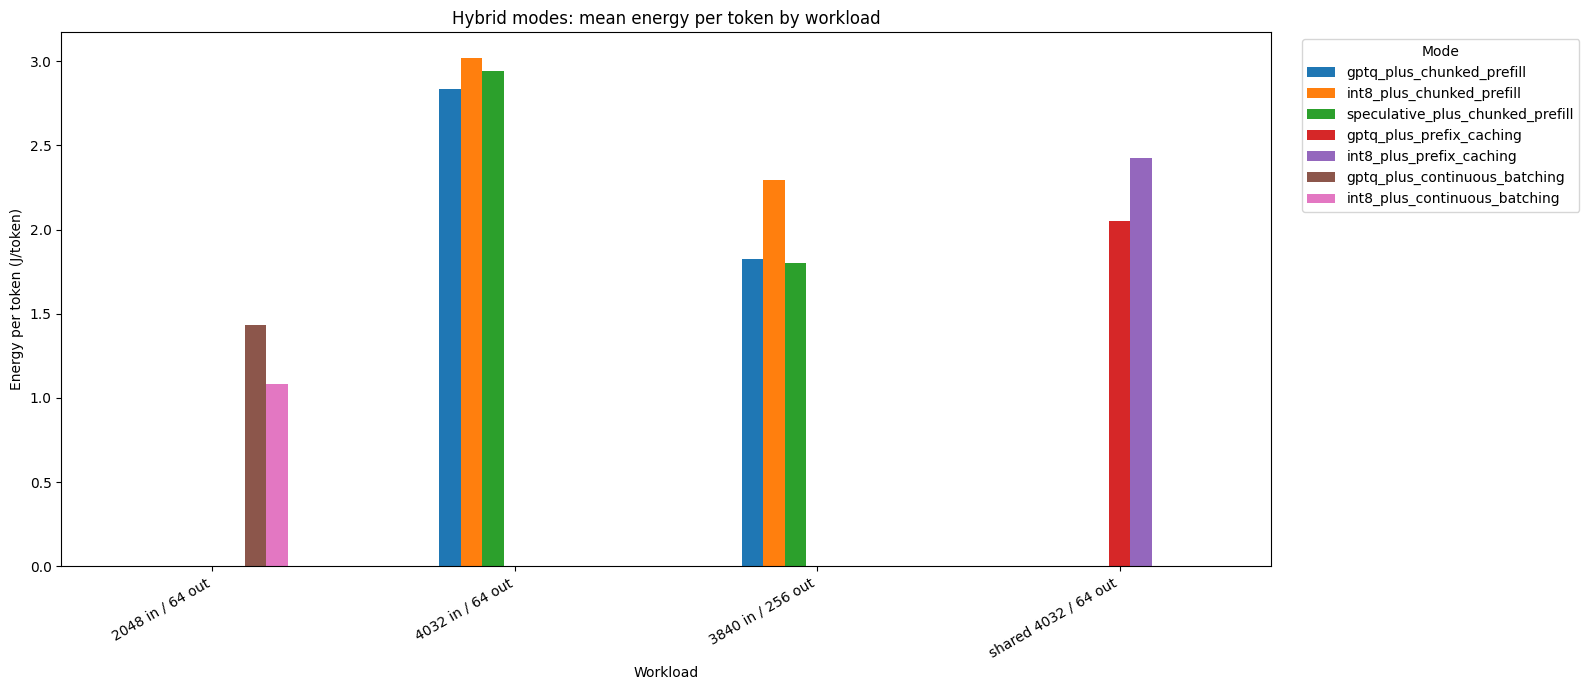

In [35]:
# hybrid modes — energy per token

hybrid_energy_pivot = hybrid_agg_df.pivot(
    index="workload_label",
    columns="mode_name",
    values="energy_per_token_j_mean"
).reindex(index=hybrid_plot_workloads, columns=hybrid_mode_order)

ax = hybrid_energy_pivot.plot(kind="bar", figsize=(16, 7))
ax.set_title("Hybrid modes: mean energy per token by workload")
ax.set_ylabel("Energy per token (J/token)")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

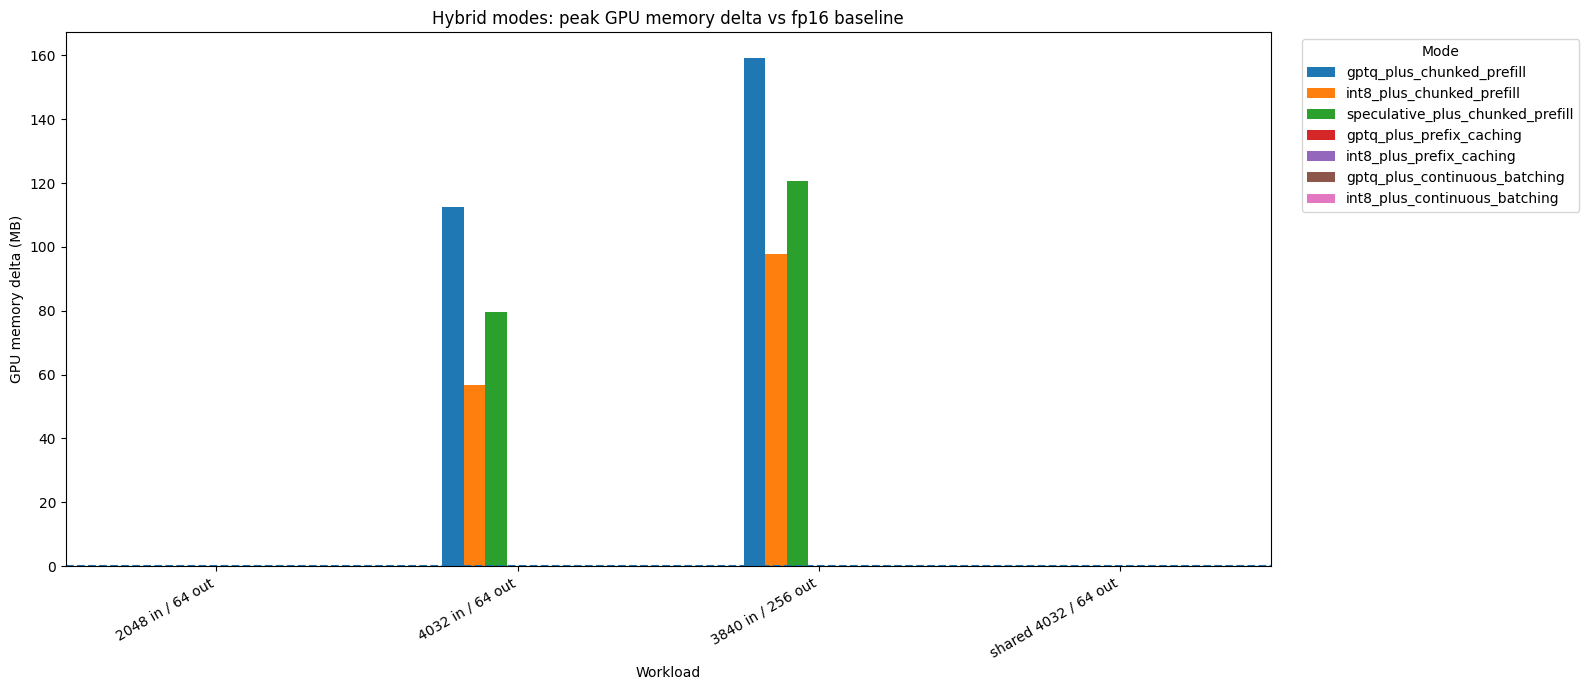

In [49]:
# hybrid modes — peak GPU memory delta vs fp16 baseline

hybrid_mem_df = hybrid_agg_df[
    ["mode_name", "workload_name", "workload_label", "peak_gpu_memory_mb_mean"]
].copy()

# use fp16 rows from the single-mode aggregate table as the reference anchor
hybrid_mem_baseline = single_agg_df[single_agg_df["mode_name"] == "fp16_baseline"][
    ["workload_name", "peak_gpu_memory_mb_mean"]
].rename(columns={"peak_gpu_memory_mb_mean": "fp16_peak_gpu_memory_mb_mean"})

hybrid_mem_delta_df = hybrid_mem_df.merge(hybrid_mem_baseline, on="workload_name", how="left")
hybrid_mem_delta_df["peak_gpu_memory_delta_mb_vs_fp16"] = (
    hybrid_mem_delta_df["peak_gpu_memory_mb_mean"] - hybrid_mem_delta_df["fp16_peak_gpu_memory_mb_mean"]
)

hybrid_mem_delta_pivot = hybrid_mem_delta_df.pivot(
    index="workload_label",
    columns="mode_name",
    values="peak_gpu_memory_delta_mb_vs_fp16"
).reindex(index=hybrid_plot_workloads, columns=hybrid_mode_order)

ax = hybrid_mem_delta_pivot.plot(kind="bar", figsize=(16, 7))
ax.set_title("Hybrid modes: peak GPU memory delta vs fp16 baseline")
ax.set_ylabel("GPU memory delta (MB)")
ax.set_xlabel("Workload")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.axhline(0, linestyle="--")
ax.legend(title="Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [37]:
# compare hybrids against their corresponding single base mode
# This is only done where the matching single-mode workload exists.

hybrid_base_mode_map = {
    "gptq_plus_chunked_prefill": "gptq_4bit",
    "int8_plus_chunked_prefill": "int8_quant",
    "speculative_plus_chunked_prefill": "speculative_decoding",
    "gptq_plus_prefix_caching": "gptq_4bit",
    "int8_plus_prefix_caching": "int8_quant",
    "gptq_plus_continuous_batching": "gptq_4bit",
    "int8_plus_continuous_batching": "int8_quant",
}

hybrid_ok_df["base_mode_name"] = hybrid_ok_df["mode_name"].map(hybrid_base_mode_map)

base_single_df = single_ok_df[
    ["mode_name", "workload_name", "trial_index", "total_latency_ms", "tokens_per_second", "energy_per_token_j"]
].rename(
    columns={
        "mode_name": "base_mode_name",
        "total_latency_ms": "base_total_latency_ms",
        "tokens_per_second": "base_tokens_per_second",
        "energy_per_token_j": "base_energy_per_token_j",
    }
)

hybrid_vs_base_df = hybrid_ok_df.merge(
    base_single_df,
    on=["base_mode_name", "workload_name", "trial_index"],
    how="inner"
).copy()

hybrid_vs_base_df["latency_speedup_vs_base"] = hybrid_vs_base_df["base_total_latency_ms"] / hybrid_vs_base_df["total_latency_ms"]
hybrid_vs_base_df["throughput_ratio_vs_base"] = hybrid_vs_base_df["tokens_per_second"] / hybrid_vs_base_df["base_tokens_per_second"]
hybrid_vs_base_df["energy_ratio_vs_base"] = hybrid_vs_base_df["energy_per_token_j"] / hybrid_vs_base_df["base_energy_per_token_j"]

hybrid_vs_base_rows = []
for (mode_name, workload_name), group in hybrid_vs_base_df.groupby(["mode_name", "workload_name"], sort=False):
    row = {
        "mode_name": mode_name,
        "workload_name": workload_name,
        "workload_label": workload_label_map.get(workload_name, workload_name),
        "num_paired_runs": len(group),
    }
    row.update(summarize_metric(group["latency_speedup_vs_base"], "latency_speedup_vs_base"))
    row.update(summarize_metric(group["throughput_ratio_vs_base"], "throughput_ratio_vs_base"))
    row.update(summarize_metric(group["energy_ratio_vs_base"], "energy_ratio_vs_base"))
    hybrid_vs_base_rows.append(row)

hybrid_vs_base_summary_df = pd.DataFrame(hybrid_vs_base_rows)

display(hybrid_vs_base_summary_df.sort_values(["workload_name", "latency_speedup_vs_base_mean"], ascending=[True, False]))

,mode_name,workload_name,workload_label,num_paired_runs,latency_speedup_vs_base_mean,latency_speedup_vs_base_std,latency_speedup_vs_base_median,latency_speedup_vs_base_p95,latency_speedup_vs_base_ci95_low,latency_speedup_vs_base_ci95_high,...,throughput_ratio_vs_base_median,throughput_ratio_vs_base_p95,throughput_ratio_vs_base_ci95_low,throughput_ratio_vs_base_ci95_high,energy_ratio_vs_base_mean,energy_ratio_vs_base_std,energy_ratio_vs_base_median,energy_ratio_vs_base_p95,energy_ratio_vs_base_ci95_low,energy_ratio_vs_base_ci95_high
2,gptq_plus_chunked_prefill,ctx3840_out256,3840 in / 256 out,10,1.122337,0.069508,1.143401,1.185060,1.079256,1.165419,...,1.143401,1.185060,1.079256,1.165419,0.925608,0.044251,0.914515,0.999113,0.898181,0.953034
0,int8_plus_chunked_prefill,ctx3840_out256,3840 in / 256 out,10,0.999789,0.028515,0.991918,1.043743,0.982115,1.017463,...,0.991918,1.043743,0.982115,1.017463,0.981742,0.040428,0.992030,1.016236,0.956684,1.006800
5,speculative_plus_chunked_prefill,ctx3840_out256,3840 in / 256 out,10,0.993659,0.007071,0.990781,1.002863,0.989276,0.998042,...,0.990781,1.002863,0.989276,0.998042,1.001548,0.030658,1.003270,1.043274,0.982546,1.020550
4,gptq_plus_chunked_prefill,ctx4032_out64,4032 in / 64 out,10,1.001831,0.015267,1.000898,1.020099,0.992369,1.011294,...,1.000898,1.020099,0.992369,1.011294,1.009003,0.074221,1.011542,1.109191,0.963000,1.055006
3,speculative_plus_chunked_prefill,ctx4032_out64,4032 in / 64 out,10,0.992895,0.017459,0.991630,1.018052,0.982075,1.003716,...,0.991630,1.018052,0.982075,1.003716,0.976038,0.037450,0.969382,1.036209,0.952827,0.999250
1,int8_plus_chunked_prefill,ctx4032_out64,4032 in / 64 out,10,0.991442,0.007655,0.990740,1.003222,0.986697,0.996186,...,0.990740,1.003222,0.986697,0.996186,1.038837,0.039636,1.048170,1.089307,1.014271,1.063404


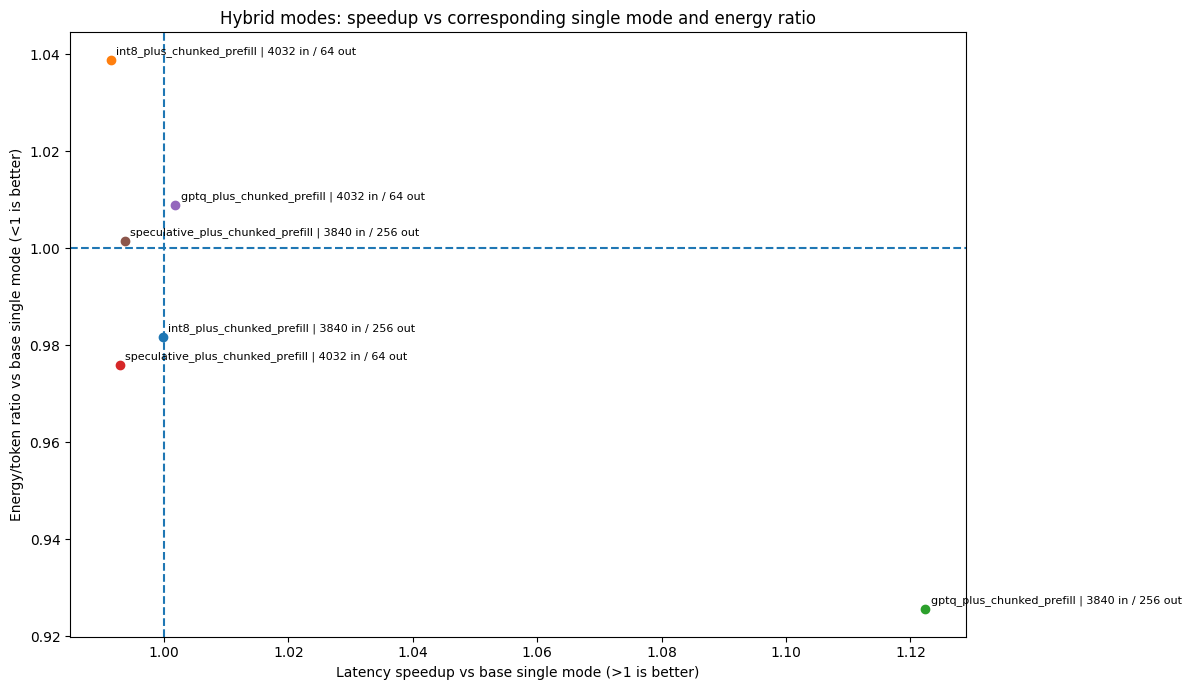

In [43]:
# hybrid modes — speedup vs base single mode and energy ratio vs base single mode

hybrid_scatter_df = hybrid_vs_base_summary_df.copy()

fig, ax = plt.subplots(figsize=(12, 7))

for _, row in hybrid_scatter_df.iterrows():
    x = row["latency_speedup_vs_base_mean"]
    y = row["energy_ratio_vs_base_mean"]
    label = f"{row['mode_name']} | {row['workload_label']}"
    ax.scatter(x, y)
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(4, 2),                  # slight right/up offset in points
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=8,
    )

ax.axvline(1.0, linestyle="--")
ax.axhline(1.0, linestyle="--")
ax.set_title("Hybrid modes: speedup vs corresponding single mode and energy ratio")
ax.set_xlabel("Latency speedup vs base single mode (>1 is better)")
ax.set_ylabel("Energy/token ratio vs base single mode (<1 is better)")
plt.tight_layout()
plt.show()

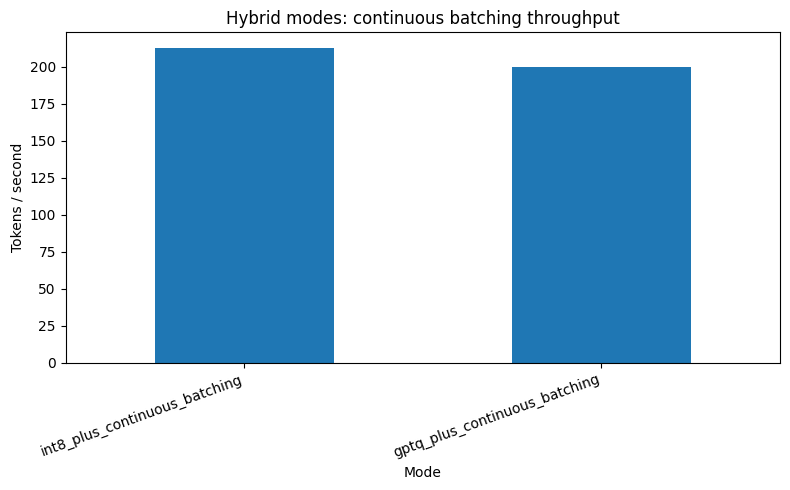

In [39]:
# hybrid modes — continuous batching special-case plot

hybrid_cb_df = hybrid_agg_df[
    hybrid_agg_df["mode_name"].isin(["int8_plus_continuous_batching", "gptq_plus_continuous_batching"])
].copy()

ax = hybrid_cb_df.set_index("mode_name")["tokens_per_second_mean"].plot(kind="bar", figsize=(8, 5))
ax.set_title("Hybrid modes: continuous batching throughput")
ax.set_ylabel("Tokens / second")
ax.set_xlabel("Mode")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

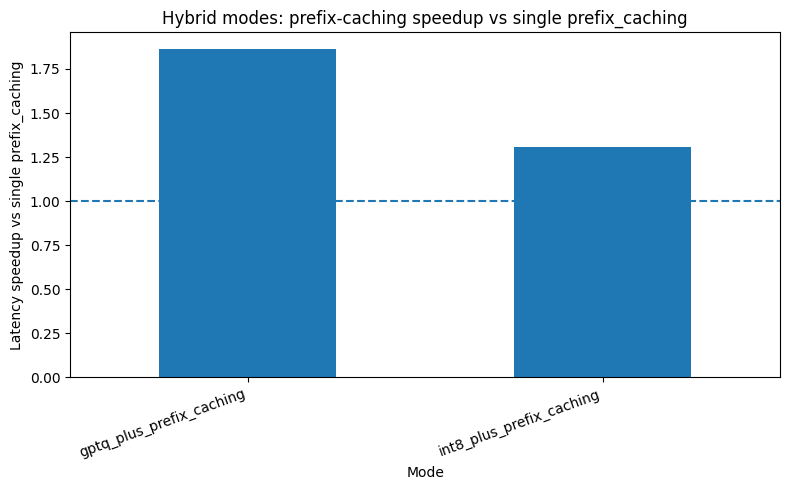

In [40]:
# hybrid modes — prefix caching special-case plot
# Compare hybrid prefix-caching modes against the single prefix_caching run.

single_prefix_latency = float(
    single_agg_df.loc[
        (single_agg_df["mode_name"] == "prefix_caching") &
        (single_agg_df["workload_name"] == "shared4032_out64"),
        "total_latency_ms_mean"
    ].iloc[0]
)

hybrid_prefix_df = hybrid_agg_df[
    hybrid_agg_df["mode_name"].isin(["gptq_plus_prefix_caching", "int8_plus_prefix_caching"])
].copy()

hybrid_prefix_df["latency_speedup_vs_single_prefix"] = single_prefix_latency / hybrid_prefix_df["total_latency_ms_mean"]

ax = hybrid_prefix_df.set_index("mode_name")["latency_speedup_vs_single_prefix"].plot(kind="bar", figsize=(8, 5))
ax.set_title("Hybrid modes: prefix-caching speedup vs single prefix_caching")
ax.set_ylabel("Latency speedup vs single prefix_caching")
ax.set_xlabel("Mode")
ax.axhline(1.0, linestyle="--")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [41]:
# best hybrid mode per workload by latency

best_hybrid_by_latency = (
    hybrid_agg_df.sort_values(["workload_name", "total_latency_ms_mean"], ascending=[True, True])
    .groupby("workload_name", as_index=False)
    .first()
)

best_hybrid_by_latency = best_hybrid_by_latency[
    [
        "workload_name",
        "mode_name",
        "ttft_ms_mean",
        "total_latency_ms_mean",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]
].copy()

display(best_hybrid_by_latency)

,workload_name,mode_name,ttft_ms_mean,total_latency_ms_mean,tokens_per_second_mean,energy_per_token_j_mean,peak_gpu_memory_mb_mean
0,ctx2048_out64,int8_plus_continuous_batching,234.742493,1203.919103,212.643896,1.082592,33377.311523
1,ctx3840_out256,speculative_plus_chunked_prefill,352.571661,2203.971474,116.155390,1.799154,33587.211426
2,ctx4032_out64,gptq_plus_chunked_prefill,322.989967,788.215273,81.208067,2.833825,33640.947754
3,shared4032_out64,gptq_plus_prefix_caching,54.320555,541.359981,118.230482,2.049363,33634.139160


## Summary of results

### Single modes

- **For 3840 in / 256 out**, the best single mode is **speculative_decoding**. It gives the best end-to-end latency, the highest throughput, and the lowest energy per token among the single modes tested.
- **For 4032 in / 64 out**, the best single mode is **gptq_4bit**. It is the fastest on total latency and also slightly better than speculative decoding on energy for this workload.
- **If first-token responsiveness matters most**, **int8_quant** has the best TTFT on both non-shared long-context workloads, even though it is not the fastest overall on total latency.
- **For shared-prefix repeated requests**, **prefix_caching** is the right single-mode choice. Its TTFT is dramatically lower than the non-cached modes on the shared-prefix workload.
- **continuous_batching** should be treated as a throughput-oriented serving configuration, not as the best single-request interactive mode. It improves throughput, but its total latency is worse than the fastest interactive single modes.
- **chunked_prefill** did not win any of the single-mode workloads here. It improves a lot over fp16 baseline, but it still trails the best quantized or speculative single modes.

### Hybrid modes

- **For shared-prefix repeated requests, the best hybrid is clearly `gptq_plus_prefix_caching`**. This is the strongest hybrid result in the whole notebook. It is much faster than single `prefix_caching`, and it also beats `int8_plus_prefix_caching`.
- **`int8_plus_prefix_caching`** is also a real improvement over single `prefix_caching`, but it is not as strong as the GPTQ + prefix-caching combination.
- **For 3840 in / 256 out**, the best hybrid by latency is **`speculative_plus_chunked_prefill`**, with **`gptq_plus_chunked_prefill`** very close behind. But these do **not** meaningfully outperform the best single mode, which is already `speculative_decoding`.
- **For 4032 in / 64 out**, **`gptq_plus_chunked_prefill`** is the best hybrid, but it is effectively tied with plain `gptq_4bit`. So this hybrid does not really justify itself on this workload.
- **`int8_plus_chunked_prefill`** does not improve over plain `int8_quant` on the tested long-context workloads.
- **For the 2048 in / 64 out continuous-batching workload**, **`int8_plus_continuous_batching`** is the better hybrid compared with `gptq_plus_continuous_batching`, with better latency, better throughput, lower energy, and lower memory.

### Bottom line

- **Single modes are enough for most of these workloads.**
- The two strongest single-mode choices are:
  - **`speculative_decoding`** for long-output interactive generation
  - **`gptq_4bit`** for long-context short-output interactive generation
- **Hybrids are mainly worth it in two places**:
  - **shared-prefix traffic**, especially **`gptq_plus_prefix_caching`**
  - **batched throughput-oriented serving**, where **`int8_plus_continuous_batching`** looks best among the batching hybrids
- The chunked-prefill hybrids do not show a broad win here; at best they are neutral, and in several cases they are slightly worse than the best single mode.